In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score,adjusted_rand_score,normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [3]:

x=pd.read_csv("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_8/Datasets/UCI HAR Dataset/UCI HAR Dataset/train/X_train.txt",sep=r"\s+",header=None)
y=pd.read_csv("C:/Users/DHARSHINI/Downloads/sem5/ml_lab/Assignment_8/Datasets/UCI HAR Dataset/UCI HAR Dataset/train/y_train.txt",header=None)

In [4]:
print(x.head())
print(y.head())

        0         1         2         3         4         5         6    \
0  0.288585 -0.020294 -0.132905 -0.995279 -0.983111 -0.913526 -0.995112   
1  0.278419 -0.016411 -0.123520 -0.998245 -0.975300 -0.960322 -0.998807   
2  0.279653 -0.019467 -0.113462 -0.995380 -0.967187 -0.978944 -0.996520   
3  0.279174 -0.026201 -0.123283 -0.996091 -0.983403 -0.990675 -0.997099   
4  0.276629 -0.016570 -0.115362 -0.998139 -0.980817 -0.990482 -0.998321   

        7         8         9    ...       551       552       553       554  \
0 -0.983185 -0.923527 -0.934724  ... -0.074323 -0.298676 -0.710304 -0.112754   
1 -0.974914 -0.957686 -0.943068  ...  0.158075 -0.595051 -0.861499  0.053477   
2 -0.963668 -0.977469 -0.938692  ...  0.414503 -0.390748 -0.760104 -0.118559   
3 -0.982750 -0.989302 -0.938692  ...  0.404573 -0.117290 -0.482845 -0.036788   
4 -0.979672 -0.990441 -0.942469  ...  0.087753 -0.351471 -0.699205  0.123320   

        555       556       557       558       559       560  
0  0

In [5]:
print(x.shape)
print(y.shape)

print("Missing Values in X :", x.isnull().sum().sum())
print("Missing Values in Y :", y.isnull().sum().sum())

(7352, 561)
(7352, 1)
Missing Values in X : 0
Missing Values in Y : 0


In [6]:
print(y[0].unique())

[5 4 6 1 3 2]


In [7]:
scaler=StandardScaler()

x_scaled=scaler.fit_transform(x)

print(x_scaled.shape)

(7352, 561)


In [8]:
pca=PCA(n_components=2)

x_pca=pca.fit_transform(x_scaled)

print(x_pca.shape)

(7352, 2)


In [13]:
kmeans=KMeans(n_clusters=6,random_state=42)

kmeans_labels=kmeans.fit_predict(x_scaled)

print(np.unique(kmeans_labels))

kmeans_sil = silhouette_score(
    x_scaled,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    x_scaled,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    x_scaled,
    kmeans_labels
)

kmeans_ari = adjusted_rand_score(
    y.values.ravel(),
    kmeans_labels
)

kmeans_nmi = normalized_mutual_info_score(
    y.values.ravel(),
    kmeans_labels
)

print("Silhouette :", kmeans_sil)
print("Davies-Bouldin :", kmeans_db)
print("Calinski-Harabasz :", kmeans_ch)
print("ARI :", kmeans_ari)
print("NMI :", kmeans_nmi)

[0 1 2 3 4 5]
Silhouette : 0.1086410631864108
Davies-Bouldin : 2.3579675526882222
Calinski-Harabasz : 1862.506263577485
ARI : 0.41971368603551157
NMI : 0.5589238295237167


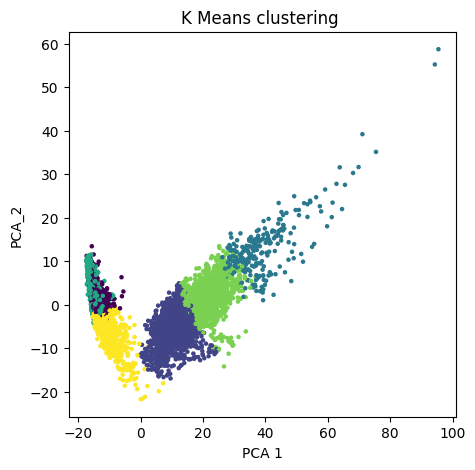

In [10]:
plt.figure(figsize=(5,5))

plt.scatter(x_pca[:,0],x_pca[:,1],c=kmeans_labels,cmap='viridis',s=5)
plt.title("K Means clustering ")
plt.xlabel("PCA 1")
plt.ylabel("PCA_2")
plt.show()

In [14]:
wcss=[]

silhoue_score=[]

for k in range(2,9,1):
    kmeans=KMeans(n_clusters=k,random_state=42)
    
    kmeans.fit(x_scaled)
    
    wcss.append(kmeans.inertia_)

    labels = kmeans.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)
    
    silhoue_score.append(score)

print(wcss)
print(silhoue_score)

[2336223.7949465243, 2081849.6271975674, 1976475.199951482, 1875068.026844911, 1818790.0682136677, 1776518.7291605163, 1748685.3431013913]
[0.39650058094388707, 0.3274077920801447, 0.1613320617042328, 0.13064369861760422, 0.1086410631864108, 0.11142407811150756, 0.08959204796105176]


In [15]:
result_table = pd.DataFrame({
    "K": range(2,9),
    "WCSS": wcss,
    "Silhouette Score": silhoue_score
})

print(result_table)

   K          WCSS  Silhouette Score
0  2  2.336224e+06          0.396501
1  3  2.081850e+06          0.327408
2  4  1.976475e+06          0.161332
3  5  1.875068e+06          0.130644
4  6  1.818790e+06          0.108641
5  7  1.776519e+06          0.111424
6  8  1.748685e+06          0.089592


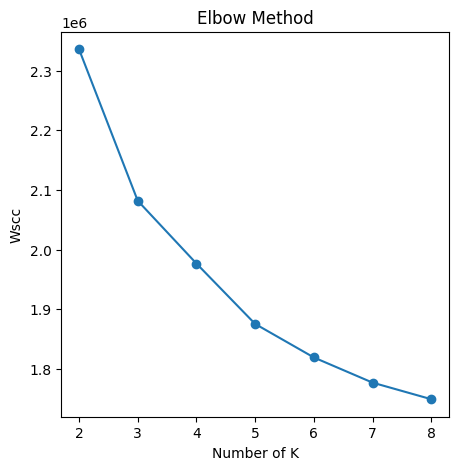

In [18]:
plt.figure(figsize=(5,5))

plt.plot(range(2,9,1),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of K')
plt.ylabel('Wscc')
plt.show()

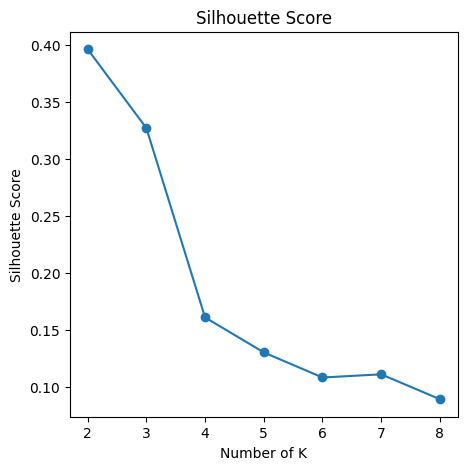

In [19]:
plt.figure(figsize=(5,5))

plt.plot(range(2,9),silhoue_score,marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of K')
plt.ylabel('Silhouette Score')
plt.show()

In [20]:
dbscan = DBSCAN(eps=1.5,min_samples=10)

db_labels=dbscan.fit_predict(x_pca)

sb_cluster_list=set(db_labels)

print(sb_cluster_list)

{0, 1, 2, 3, -1}


In [21]:
noise=0

for ele in sb_cluster_list:  
    if (ele==-1):
        noise=noise+1
        
print(noise)    

1


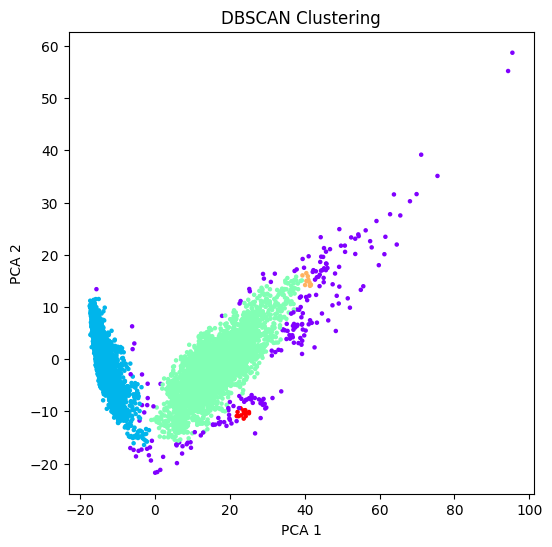

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(x_pca[:,0],x_pca[:,1],c=db_labels,cmap='rainbow',s=5)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [23]:

if len(set(db_labels)) > 1:

    print("Silhouette Score:",
          silhouette_score(x_pca, db_labels))

    print("Davies-Bouldin Index:",
          davies_bouldin_score(x_pca, db_labels))

    print("Calinski-Harabasz Index:",
          calinski_harabasz_score(x_pca, db_labels))

print("ARI:",
      adjusted_rand_score(
          y.values.ravel(),
          db_labels
      ))

print("NMI:",
      normalized_mutual_info_score(
          y.values.ravel(),
          db_labels
      ))

Silhouette Score: 0.490960875197007
Davies-Bouldin Index: 1.377583115821548
Calinski-Harabasz Index: 6437.629875579848
ARI: 0.3266064560591039
NMI: 0.5230949748586399


In [24]:
hac = AgglomerativeClustering(n_clusters=6,linkage='ward')

hac_labels = hac.fit_predict(x_scaled)

print(set(hac_labels))

{0, 1, 2, 3, 4, 5}


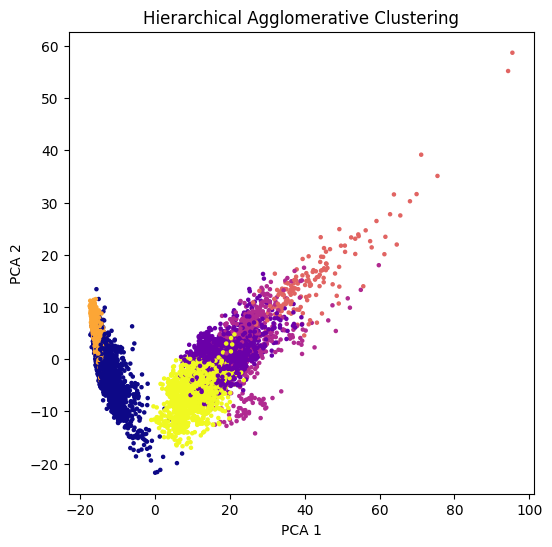

In [25]:

plt.figure(figsize=(6,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=hac_labels,cmap='plasma',s=5)
plt.title("Hierarchical Agglomerative Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

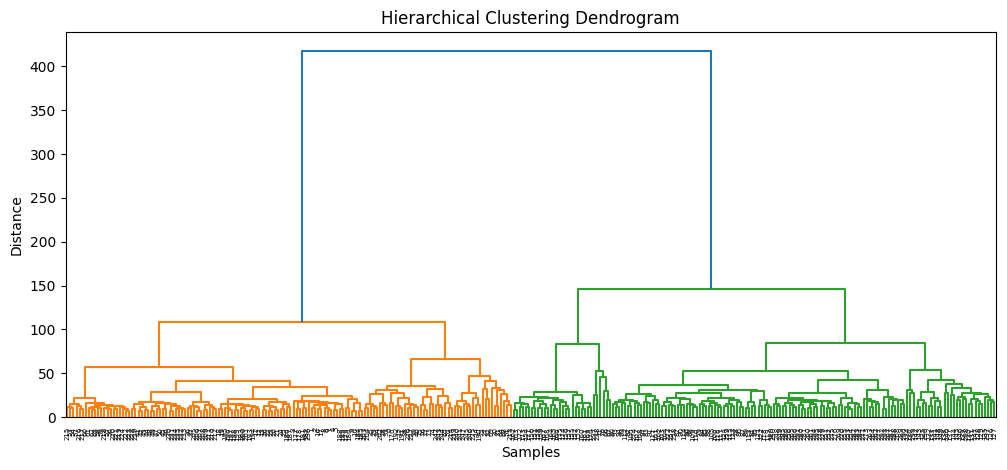

In [26]:
sample = x_scaled[:300]

Z = linkage(sample,method='ward')

plt.figure(figsize=(12,5))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

In [27]:
hac_sil = silhouette_score(
    x_scaled,
    hac_labels
)

hac_db = davies_bouldin_score(
    x_scaled,
    hac_labels
)

hac_ch = calinski_harabasz_score(
    x_scaled,
    hac_labels
)

hac_ari = adjusted_rand_score(
    y.values.ravel(),
    hac_labels
)

hac_nmi = normalized_mutual_info_score(
    y.values.ravel(),
    hac_labels
)

print("Silhouette:", hac_sil)
print("Davies-Bouldin:", hac_db)
print("Calinski-Harabasz:", hac_ch)
print("ARI:", hac_ari)
print("NMI:", hac_nmi)

Silhouette: 0.08339649239977742
Davies-Bouldin: 2.7857334406214562
Calinski-Harabasz: 1730.8358392108255
ARI: 0.2793864491481101
NMI: 0.4544001173140205


In [28]:
comparison = pd.DataFrame({
    "Algorithm":[
        "KMeans",
        "DBSCAN",
        "Hierarchical"
    ],

    "Silhouette":[
        kmeans_sil,
        silhouette_score(x_pca, db_labels),
        hac_sil
    ],

    "Davies_Bouldin":[
        kmeans_db,
        davies_bouldin_score(x_pca, db_labels),
        hac_db
    ],

    "Calinski_Harabasz":[
        kmeans_ch,
        calinski_harabasz_score(x_pca, db_labels),
        hac_ch
    ],

    "ARI":[
        kmeans_ari,
        adjusted_rand_score(
            y.values.ravel(),
            db_labels
        ),
        hac_ari
    ],

    "NMI":[
        kmeans_nmi,
        normalized_mutual_info_score(
            y.values.ravel(),
            db_labels
        ),
        hac_nmi
    ]
})

print(comparison)

      Algorithm  Silhouette  Davies_Bouldin  Calinski_Harabasz       ARI  \
0        KMeans    0.108641        2.357968        1862.506264  0.419714   
1        DBSCAN    0.490961        1.377583        6437.629876  0.326606   
2  Hierarchical    0.083396        2.785733        1730.835839  0.279386   

        NMI  
0  0.558924  
1  0.523095  
2  0.454400  


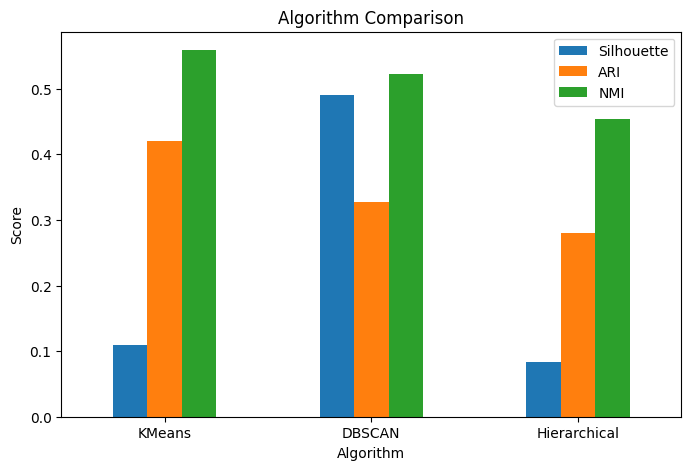

In [29]:
comparison.set_index(
    "Algorithm"
)[["Silhouette","ARI","NMI"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Algorithm Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()